In [1]:
!pip install paddlepaddle-gpu paddleocr -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.7/415.7 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: PyYAML
    Found existing installation

In [2]:
# Đảm bảo đang ở thư mục /kaggle/working
%cd /kaggle/working/

# Tải lại bộ trọng số Pretrained v4 Mobile (Dành cho English/Vietnamese)
!wget -c https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_train.tar
# Giải nén
!tar -xf en_PP-OCRv4_rec_train.tar

/kaggle/working
--2026-04-17 07:22:34--  https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_train.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.47.176, 2402:2b40:7000:913:0:ff:b0a4:a156
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.47.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 190740480 (182M) [application/x-tar]
Saving to: ‘en_PP-OCRv4_rec_train.tar’

en_PP-OCRv4_rec_tra 100%[===================>] 181.90M  19.0MB/s    in 31s     

2026-04-17 07:23:07 (5.88 MB/s) - ‘en_PP-OCRv4_rec_train.tar’ saved [190740480/190740480]



In [3]:
!ls -F en_PP-OCRv4_rec_train/

best_accuracy.pdopt  best_accuracy.pdparams  best_accuracy.states


In [4]:
# 2. Clone source code PaddleOCR
!git clone https://github.com/PaddlePaddle/PaddleOCR.git
%cd PaddleOCR

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 333268, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 333268 (delta 88), reused 73 (delta 73), pack-reused 333163 (from 2)
Receiving objects: 100% (333268/333268), 1.77 GiB | 32.79 MiB/s, done.
Resolving deltas: 100% (264056/264056), done.
/kaggle/working/PaddleOCR


In [5]:
# 3. Cài các thư viện bổ trợ cho Paddle
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.9 MB/s eta 0:00:00


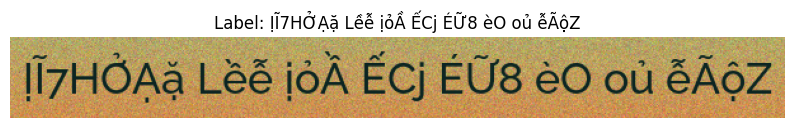

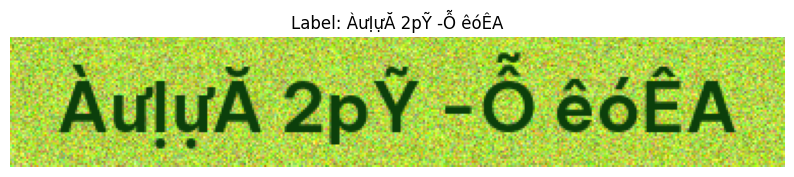

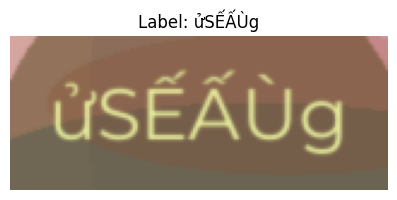

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Đường dẫn gốc tới dataset 200k của Đức
data_root = '/kaggle/input/datasets/b22dckh032hongngcc/200000/dataset/'
label_path = os.path.join(data_root, 'train.txt')

# 2. Đọc thử một vài dòng ngẫu nhiên để kiểm tra độ đa dạng
with open(label_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Chọn thử 3 mẫu ngẫu nhiên để xem
import random
samples = random.sample(lines, 3)

for line in samples:
    parts = line.strip().split('\t')
    if len(parts) < 2:
        continue
        
    img_name, label = parts[0], parts[1]
    
    # 3. Kết hợp data_root với tên ảnh từ file label
    img_path = os.path.join(data_root, img_name)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Không tìm thấy ảnh: {img_path}")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 2))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

In [ ]:
import yaml
import os

config_path = '/kaggle/working/PaddleOCR/mobile_v4_final.yml'
# Đường dẫn gốc đến bộ dataset 200k của Đức
data_root = '/kaggle/input/datasets/b22dckh032hongngcc/200000/dataset/'

# Tạo thư mục chứa config nếu chưa có
os.makedirs(os.path.dirname(config_path), exist_ok=True)

final_config = {
    'Global': {
        'use_gpu': True,
        'distributed': True,
        'epoch_num': 10,
        'batch_size_per_card': 64, 
        'eval_batch_step': [0, 500], 
        'save_epoch_step': 1,
        'log_smooth_window': 20,
        'print_batch_step': 10,
        'character_dict_path': data_root + 'vietnamese_dict.txt',
        'use_space_char': True,
        'save_model_dir': './output/v4_mobile_200k_pretrained',
        
        # SỬA TẠI ĐÂY: Trỏ vào bộ Pretrained Đức vừa wget và giải nén
        'pretrained_model': '/kaggle/working/en_PP-OCRv4_rec_train/best_accuracy',
        
        'max_text_length': 25,
        'cal_metric_during_train': True
    },
    'Optimizer': {
        'name': 'Adam',
        'beta1': 0.9,
        'beta2': 0.999,
        'lr': {
            'name': 'Cosine',
            'learning_rate': 0.0005, 
            'warmup_epoch': 2
        },
        'regularizer': {
            'name': 'L2',
            'factor': 3.0e-05
        }
    },
    'Architecture': {
        'model_type': 'rec',
        'algorithm': 'SVTR_LCNet',
        'Backbone': {'name': 'PPLCNetV3', 'scale': 0.95},
        'Head': {
            'name': 'MultiHead',
            'head_list': [
                {
                    'CTCHead': {
                        'Neck': {'name': 'svtr', 'dims': 120, 'depth': 2, 'hidden_dims': 120, 'kernel_size': [1, 3], 'use_guide': True},
                        'Head': {'fc_decay': 1e-05}
                    }
                },
                {
                    'NRTRHead': {'nrtr_dim': 384, 'max_text_length': 25}
                }
            ]
        }
    },
    'Loss': {
        'name': 'MultiLoss',
        'loss_config_list': [{'CTCLoss': None}, {'NRTRLoss': None}]
    },
    'PostProcess': {'name': 'CTCLabelDecode'},
    'Metric': {'name': 'RecMetric', 'main_indicator': 'acc'},
    'Train': {
        'dataset': {
            'name': 'SimpleDataSet',
            'data_dir': data_root,
            'label_file_list': [data_root + 'train.txt'],
            'transforms': [
                {'DecodeImage': {'img_mode': 'BGR', 'channel_first': False}},
                {'MultiLabelEncode': {'gtc_encode': 'NRTRLabelEncode', 'max_text_length': 25}},
                {'RecResizeImg': {'image_shape': [3, 48, 320]}},
                {'KeepKeys': {'keep_keys': ['image', 'label_ctc', 'label_gtc', 'length', 'valid_ratio']}}
            ]
        },
        'loader': {'shuffle': True, 'batch_size_per_card': 64, 'drop_last': True, 'num_workers': 4}
    },
    'Eval': {
        'dataset': {
            'name': 'SimpleDataSet',
            'data_dir': data_root,
            'label_file_list': [data_root + 'val.txt'],
            'transforms': [
                {'DecodeImage': {'img_mode': 'BGR', 'channel_first': False}},
                {'MultiLabelEncode': {'gtc_encode': 'NRTRLabelEncode', 'max_text_length': 25}},
                {'RecResizeImg': {'image_shape': [3, 48, 320]}},
                {'KeepKeys': {'keep_keys': ['image', 'label_ctc', 'label_gtc', 'length', 'valid_ratio']}}
            ]
        },
        'loader': {'shuffle': False, 'batch_size_per_card': 64, 'drop_last': False, 'num_workers': 4}
    },
    'Test': {
        'dataset': {
            'name': 'SimpleDataSet',
            'data_dir': data_root,
            'label_file_list': [data_root + 'test.txt'],
            'transforms': [
                {'DecodeImage': {'img_mode': 'BGR', 'channel_first': False}},
                {'MultiLabelEncode': {'gtc_encode': 'NRTRLabelEncode', 'max_text_length': 25}},
                {'RecResizeImg': {'image_shape': [3, 48, 320]}},
                {'KeepKeys': {'keep_keys': ['image', 'label_ctc', 'label_gtc', 'length', 'valid_ratio']}}
            ]
        },
        'loader': {'shuffle': False, 'batch_size_per_card': 64, 'drop_last': False, 'num_workers': 4}
    }
}

with open(config_path, 'w', encoding='utf-8') as f:
    yaml.dump(final_config, f, default_flow_style=False)

print("Đã cập nhật đường dẫn Pretrained mới. Đức có thể bấm Train ngay!")

In [8]:
!python -m paddle.distributed.launch --gpus '0,1' /kaggle/working/PaddleOCR/tools/train.py \
    -c /kaggle/working/PaddleOCR/mobile_v4_final.yml

LAUNCH INFO 2026-04-17 07:25:23,713 -----------  Configuration  ----------------------
LAUNCH INFO 2026-04-17 07:25:23,714 auto_parallel_config: None
LAUNCH INFO 2026-04-17 07:25:23,714 auto_tuner_json: None
LAUNCH INFO 2026-04-17 07:25:23,714 devices: 0,1
LAUNCH INFO 2026-04-17 07:25:23,714 elastic_level: -1
LAUNCH INFO 2026-04-17 07:25:23,714 elastic_timeout: 30
LAUNCH INFO 2026-04-17 07:25:23,714 enable_gpu_log: True
LAUNCH INFO 2026-04-17 07:25:23,714 gloo_port: 6767
LAUNCH INFO 2026-04-17 07:25:23,714 host: None
LAUNCH INFO 2026-04-17 07:25:23,714 ips: None
LAUNCH INFO 2026-04-17 07:25:23,714 job_id: default
LAUNCH INFO 2026-04-17 07:25:23,714 legacy: False
LAUNCH INFO 2026-04-17 07:25:23,714 log_dir: log
LAUNCH INFO 2026-04-17 07:25:23,714 log_level: INFO
LAUNCH INFO 2026-04-17 07:25:23,714 log_overwrite: False
LAUNCH INFO 2026-04-17 07:25:23,714 master: None
LAUNCH INFO 2026-04-17 07:25:23,714 max_restart: 3
LAUNCH INFO 2026-04-17 07:25:23,714 nnodes: 1
LAUNCH INFO 2026-04-17 07

In [ ]:
!python /kaggle/working/PaddleOCR/tools/export_model.py \
    -c /kaggle/working/PaddleOCR/mobile_v4_final.yml \
    -o Global.pretrained_model=./output/v4_mobile_200k_pretrained/best_accuracy \
    -o Global.save_inference_dir=./inference/v4_mobile_card_model \
    -o Global.character_dict_path='/kaggle/input/datasets/b22dckh032hongngcc/200000/dataset/vietnamese_dict.txt'  

Skipping import of the encryption module.
W0417 13:32:01.031742  9708 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0417 13:32:01.032778  9708 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[2026/04/17 13:32:01] ppocr WARNING: The shape of model params head.ctc_head.fc.weight [120, 215] not matched with loaded params head.ctc_head.fc.weight [120, 97] !
[2026/04/17 13:32:01] ppocr WARNING: The shape of model params head.ctc_head.fc.bias [215] not matched with loaded params head.ctc_head.fc.bias [97] !
[2026/04/17 13:32:01] ppocr WARNING: The shape of model params head.gtc_head.embedding.embedding.weight [219, 384] not matched with loaded params head.gtc_head.embedding.embedding.weight [101, 384] !
[2026/04/17 13:32:01] ppocr WARNING: The shape of model params head.gtc_head.tgt_word_prj.weight [384, 219] not matched with loaded params head.gtc_head.tgt_word_prj.weight [384, 101] !
[2026/04/17 13:32:01